# Hit 25 — vector-fields comparison (MSE vs. Chamfer vs. Ground Truth)

Reproduces the `vector_fields_loss` plot (see `forge_net/utils/plotting.py::visualize_vector_diff_w_loss_cont`, called from `forge_net/eval.py::evaluate` for every `idx` in `config["eval"]["eval_idxs"]`) for evaluation index **25** (`eval_idxs: [1, 25, 115]` in every experiment config — "hit 25" is that index), and stacks the result for two model checkpoints plus ground truth into a single 3-row, 1-column figure with **one shared colorbar**:

1. `mse_1024_unmasked_seeded_tri_ids` — predicted vector field, colored by per-point Euclidean distance error
2. `chamfer_1024_unmasked_seeded_tri_ids` — predicted vector field, colored by per-point Euclidean distance error
3. Ground truth vector field, distance error = 0 everywhere (shares the same color scale/colorbar as rows 1-2, so it renders at the bottom of the color range)

Both rows are colored by the same metric — per-point Euclidean distance `||x_hat - x_gt||` between predicted and true point position — rather than each model's own training loss (MSE's squared error vs. Chamfer's nearest-neighbor distance use different formulas and scales, so they weren't directly comparable). Euclidean distance is a common, model-agnostic metric already used elsewhere in this codebase for cross-model comparison (e.g. `rec_step_dist_means` in `evaluate_series`).

The color scale is deliberately **not** symmetric: `vmax` is set from the MSE model's own max distance error, giving it full dynamic range, while the Chamfer model's (larger) errors are allowed to oversaturate past that ceiling — visually showing that it's worse, rather than compressing both into one washed-out scale.

## Why this notebook exists as a standalone artifact

The `models/forge-net` submodule was refactored from PyTorch/`ForgeNetTrainer` to JAX/Flax/Optax (see submodule commit `17e13ad`, "jax refactor working fanglei updates"). The `main.py` on this branch expects an Optax-trained model, but `mse_1024_unmasked_seeded_tri_ids` and `chamfer_1024_unmasked_seeded_tri_ids` are `best_model.pth` checkpoints trained with the **old PyTorch** `ForgeNet`/`ForgeNetTrainer` (last present at submodule commit `0af2b35`, right before the refactor).

Rather than write a PyTorch→Optax weight converter, this notebook inlines the old PyTorch model (verbatim from that commit) so it can load the `.pth` checkpoints directly — no conversion needed, and no dependency on the current (JAX-based) `forge_net` package, which is why the model definition is copied in below instead of imported.

**Kernel:** run this with the `forgenet` conda env (`/local/scratch/groves/miniconda3/envs/forgenet`), registered as the Jupyter kernel **"Python (forgenet)"** — it has `torch` + `pyvista` but not `jax`, which is fine since nothing here imports `forge_net`.

In [1]:
from pathlib import Path

import yaml
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import pyvista as pv
if hasattr(pv, "start_xvfb"):
    pv.start_xvfb()
pv.set_jupyter_backend("static")

In [2]:
# --- Config -----------------------------------------------------------------
FORGE_NET_ROOT = Path("/local/scratch/groves/jax-forgeRL/models/forge-net/forge_net")
RUN_MSE = "mse_1024_unmasked_seeded_tri_ids"
RUN_CHAMFER = "chamfer_1024_unmasked_seeded_tri_ids"
HIT_IDX = 25  # matches eval_idxs: [1, 25, 115] in the experiment configs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Old PyTorch `ForgeNet` architecture

Copied verbatim from `forge_net/model/model.py` at submodule commit `0af2b35` (last commit before the JAX refactor). This must match exactly for `best_model.pth`'s `state_dict` to load.

In [3]:
class ForgeNet(nn.Module):
    def __init__(self, point_size, latent_size, action_dims, dropout=0.3, use_res=True):
        super(ForgeNet, self).__init__()
        self.latent_size = int(latent_size / 2)
        self.point_size = point_size
        self.dropout = dropout
        self.use_res = use_res

        # STATE ENCODER
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, 1)
        self.bn3 = nn.BatchNorm1d(128)
        self.proj1 = nn.Conv1d(64, 128, 1)
        self.bn_proj1 = nn.BatchNorm1d(128)

        self.conv4 = nn.Conv1d(128, 256, 1)
        self.bn4 = nn.BatchNorm1d(256)
        self.proj2 = nn.Conv1d(128, 256, 1)
        self.bn_proj2 = nn.BatchNorm1d(256)

        self.conv5 = nn.Conv1d(256, self.latent_size, 1)
        self.bn5 = nn.BatchNorm1d(self.latent_size)
        self.dropout_state = nn.Dropout(dropout)

        # ACTION ENCODER
        self.act_fc1 = nn.Linear(action_dims, 64)
        self.act_bn1 = nn.BatchNorm1d(64)
        self.act_fc2 = nn.Linear(64, 64)
        self.act_bn2 = nn.BatchNorm1d(64)
        self.act_fc3 = nn.Linear(64, 128)
        self.act_bn3 = nn.BatchNorm1d(128)
        self.act_proj1 = nn.Linear(64, 128)
        self.act_bn_proj1 = nn.BatchNorm1d(128)
        self.act_fc4 = nn.Linear(128, 256)
        self.act_bn4 = nn.BatchNorm1d(256)
        self.act_proj2 = nn.Linear(128, 256)
        self.act_bn_proj2 = nn.BatchNorm1d(256)
        self.act_fc5 = nn.Linear(256, self.latent_size)
        self.dropout_action = nn.Dropout(dropout)

        # POINT-WISE DECODER
        decoder_in_dim = (self.latent_size * 2) + 3
        self.dec_conv1 = nn.Conv1d(decoder_in_dim, 512, 1)
        self.dec_bn1 = nn.BatchNorm1d(512)
        self.dec_conv2 = nn.Conv1d(512, 256, 1)
        self.dec_bn2 = nn.BatchNorm1d(256)
        self.dec_conv3 = nn.Conv1d(256, 128, 1)
        self.dec_bn3 = nn.BatchNorm1d(128)
        self.dec_proj1 = nn.Conv1d(512, 128, 1)
        self.dec_bn_proj1 = nn.BatchNorm1d(128)
        self.dec_conv4 = nn.Conv1d(128, 3, 1)
        self.dropout_dec = nn.Dropout(dropout * 0.5)

        self._build_codecs()
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _build_codecs(self):
        if self.use_res:
            def state_encoder(x):
                x = F.relu(self.bn1(self.conv1(x)))
                identity = x
                x = F.relu(self.bn2(self.conv2(x))) + identity
                identity = self.bn_proj1(self.proj1(x))
                x = F.relu(self.bn3(self.conv3(x))) + identity
                identity = self.bn_proj2(self.proj2(x))
                x = F.relu(self.bn4(self.conv4(x))) + identity
                x = self.bn5(self.conv5(x))
                x = torch.max(x, 2, keepdim=False)[0]
                return self.dropout_state(x)

            def action_encoder(a):
                if len(a.shape) == 1:
                    a = a.unsqueeze(1)
                a = F.relu(self.act_bn1(self.act_fc1(a)))
                identity = a
                a = F.relu(self.act_bn2(self.act_fc2(a))) + identity
                identity = self.act_bn_proj1(self.act_proj1(a))
                a = F.relu(self.act_bn3(self.act_fc3(a))) + identity
                identity = self.act_bn_proj2(self.act_proj2(a))
                a = F.relu(self.act_bn4(self.act_fc4(a))) + identity
                return self.act_fc5(self.dropout_action(a))

            def decoder(combined_features):
                x = F.relu(self.dec_bn1(self.dec_conv1(combined_features)))
                x = self.dropout_dec(x)
                identity = self.dec_bn_proj1(self.dec_proj1(x))
                x = F.relu(self.dec_bn2(self.dec_conv2(x)))
                x = F.relu(self.dec_bn3(self.dec_conv3(x))) + identity
                delta = self.dec_conv4(x)
                return delta.transpose(1, 2)
        else:
            def state_encoder(x):
                x = F.relu(self.bn1(self.conv1(x)))
                x = F.relu(self.bn2(self.conv2(x)))
                x = F.relu(self.bn3(self.conv3(x)))
                x = F.relu(self.bn4(self.conv4(x)))
                x = self.bn5(self.conv5(x))
                x = torch.max(x, 2, keepdim=False)[0]
                return self.dropout_state(x)

            def action_encoder(a):
                if len(a.shape) == 1:
                    a = a.unsqueeze(1)
                a = F.relu(self.act_bn1(self.act_fc1(a)))
                a = F.relu(self.act_bn2(self.act_fc2(a)))
                a = F.relu(self.act_bn3(self.act_fc3(a)))
                a = F.relu(self.act_bn4(self.act_fc4(a)))
                return self.act_fc5(self.dropout_action(a))

            def decoder(combined_features):
                x = F.relu(self.dec_bn1(self.dec_conv1(combined_features)))
                x = self.dropout_dec(x)
                x = F.relu(self.dec_bn2(self.dec_conv2(x)))
                x = F.relu(self.dec_bn3(self.dec_conv3(x)))
                delta = self.dec_conv4(x)
                return delta.transpose(1, 2)

        self.state_encoder = state_encoder
        self.action_encoder = action_encoder
        self.decoder = decoder

    def forward(self, x_t, a_t):
        B, C, N = x_t.shape
        x_l = self.state_encoder(x_t)
        a_l = self.action_encoder(a_t)
        global_latent = torch.cat([x_l, a_l], dim=1)
        global_expanded = global_latent.unsqueeze(2).expand(-1, -1, N)
        combined_features = torch.cat([global_expanded, x_t], dim=1)
        delta = self.decoder(combined_features)
        return delta

## Load configs, models, and hit 25

Mirrors `forge_net/eval.py::evaluate` (old PyTorch version, same commit) for a single `idx`, but instead of each model's own training-loss `loss_cont`, we compute the common Euclidean distance error for both.

In [4]:
def load_run_config(run_name):
    cfg_path = FORGE_NET_ROOT / "runs" / run_name / "config_out.yml"
    with open(cfg_path) as f:
        return yaml.safe_load(f)


def build_and_load_model(config, device):
    net_cfg = config["network"]
    model = ForgeNet(
        point_size=net_cfg["point_size"],
        latent_size=net_cfg["latent_size"],
        action_dims=net_cfg["action_dims"],
        dropout=net_cfg["dropout"],
        use_res=net_cfg["use_res"],
    ).to(device)
    ckpt_path = Path(config["run"]["run_folder"]) / "best_model.pth"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


def predict_hit(model, states, states_tp1, actions, idx, device):
    """Reproduces the per-idx inference block in the old eval.py::evaluate."""
    x_t = torch.tensor(states[idx], dtype=torch.float32).T.unsqueeze(0).to(device)      # (1, 3, N)
    x_tp1 = torch.tensor(states_tp1[idx], dtype=torch.float32).T.unsqueeze(0).to(device)  # (1, 3, N)
    a = torch.tensor(actions[idx], dtype=torch.float32).unsqueeze(0).to(device)          # (1, action_dims)

    x_t_np = x_t.T.squeeze().cpu().numpy()
    x_tp1_np = x_tp1.T.squeeze().cpu().numpy()

    with torch.no_grad():
        delta_hat = model(x_t, a) / 100.0  # (1, N, 3)

    x_tp1_hat_np = (x_t.squeeze(0).T + delta_hat.squeeze(0)).cpu().numpy()

    return x_t_np, x_tp1_np, x_tp1_hat_np


def euclidean_dist(x_pred, x_true):
    """Per-point Euclidean distance error, shape (N,) -- a common metric independent of training loss."""
    return np.linalg.norm(x_pred - x_true, axis=-1)

In [5]:
mse_config = load_run_config(RUN_MSE)
chamfer_config = load_run_config(RUN_CHAMFER)

assert mse_config["network"]["loss"] == "mse"
assert chamfer_config["network"]["loss"] == "chamfer"
# Both runs were trained on the same dataset/split, so hit 25 refers to the same sample either way.
assert mse_config["datasets"]["data_out"] == chamfer_config["datasets"]["data_out"]
assert mse_config["network"]["action_features"] == ["steps"] == chamfer_config["network"]["action_features"]

data_path = mse_config["datasets"]["data_out"]
print(f"Loading dataset: {data_path}")
data = np.load(data_path, allow_pickle=True)
states = data["coords_t"]
states_tp1 = data["coords_tp1"]
actions = data["steps"]  # action_features == ["steps"]
print(f"states: {states.shape}, states_tp1: {states_tp1.shape}, actions: {actions.shape}")

Loading dataset: /local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/data/datasets/seeded_unmasked_data100k_tri_ids.npz


states: (197988, 1024, 3), states_tp1: (197988, 1024, 3), actions: (197988, 1)


In [6]:
mse_model = build_and_load_model(mse_config, DEVICE)
chamfer_model = build_and_load_model(chamfer_config, DEVICE)

x_t_np, x_tp1_np, x_tp1_hat_mse = predict_hit(
    mse_model, states, states_tp1, actions, HIT_IDX, DEVICE
)
_, _, x_tp1_hat_chamfer = predict_hit(
    chamfer_model, states, states_tp1, actions, HIT_IDX, DEVICE
)

dist_mse = euclidean_dist(x_tp1_hat_mse, x_tp1_np)
dist_chamfer = euclidean_dist(x_tp1_hat_chamfer, x_tp1_np)
dist_gt = np.zeros_like(dist_mse)  # ground truth vs. itself

print(f"MSE model distance error:     min={dist_mse.min():.4f}  max={dist_mse.max():.4f}  mean={dist_mse.mean():.4f}")
print(f"Chamfer model distance error: min={dist_chamfer.min():.4f}  max={dist_chamfer.max():.4f}  mean={dist_chamfer.mean():.4f}")

MSE model distance error:     min=0.0001  max=0.0557  mean=0.0204
Chamfer model distance error: min=0.0001  max=0.1880  mean=0.0527


/tmp/ipykernel_576703/787670427.py:29: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  x_t_np = x_t.T.squeeze().cpu().numpy()


## 3-row comparison figure with a shared colorbar

Row 1: MSE model prediction (colored by per-point Euclidean distance error)  Row 2: Chamfer model prediction (colored by per-point Euclidean distance error)  Row 3: Ground truth (distance error = 0, same color scale — renders at the bottom of the colorbar).

All three rows share `clim=(0, vmax)` and the same camera view/arrow scale. `vmax` is set from the **MSE model's own max distance error** rather than the combined max — this gives the MSE row full dynamic range, while the Chamfer model's (larger) errors clip and oversaturate at the top color past that ceiling, visually communicating that it's worse rather than hiding it behind a stretched scale. Only the bottom row shows the scalar bar since it represents all three.

MSE max=0.0557  Chamfer max=0.1880  shared vmax (from MSE)=0.0557


Saved: /local/scratch/groves/jax-forgeRL/models/forge-net/forge_net/notebooks/hit25_vector_fields_loss_comparison.png


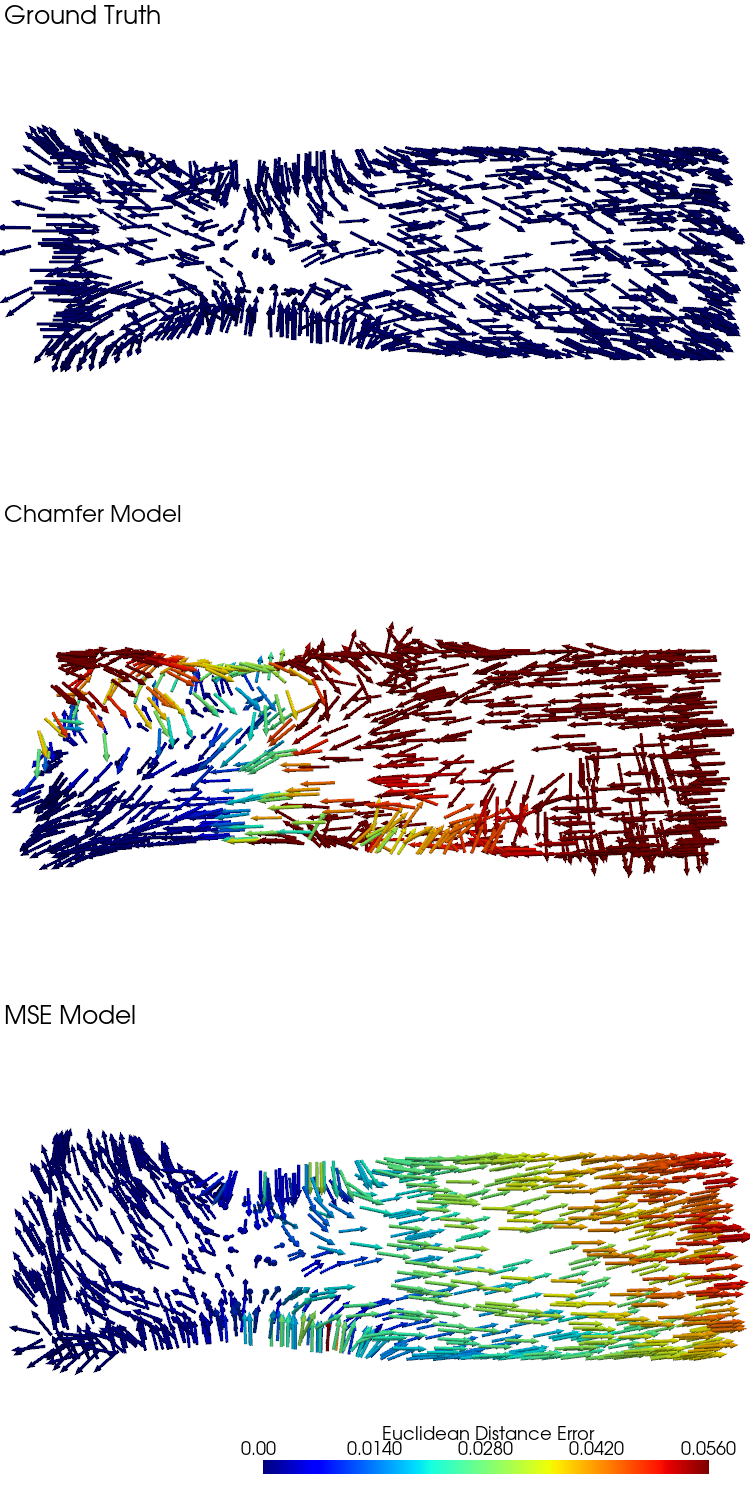

In [7]:
def add_vector_row(plotter, row, start, vectors, scalars, clim, title, show_scalar_bar, scalar_bar_args=None):
    plotter.subplot(row, 0)
    cloud = pv.PolyData(start)
    cloud["vectors"] = vectors
    cloud["dist"] = scalars
    arrows = cloud.glyph(orient="vectors", scale=False, factor=0.5, geom=pv.Arrow())
    plotter.add_mesh(
        arrows,
        scalars="dist",
        cmap="jet",
        clim=clim,
        show_scalar_bar=show_scalar_bar,
        scalar_bar_args=scalar_bar_args,
    )
    plotter.view_xy()
    plotter.camera.zoom(1.6)
    plotter.add_text(title, font_size=10)


# vmax comes from the MSE model alone, so its row gets full dynamic range. The Chamfer
# model's larger errors are left to clip/oversaturate at the top color past this ceiling --
# that's intentional: it should visually read as worse, not be hidden by a stretched scale.
vmax = float(dist_mse.max())
clim = (0.0, np.round(vmax,3))
print(f"MSE max={dist_mse.max():.4f}  Chamfer max={dist_chamfer.max():.4f}  shared vmax (from MSE)={vmax:.4f}")

# Narrow + tall (portrait) so this drops cleanly into a single column of a NeurIPS-style
# two-column layout -- width matches column width once scaled, height follows from the
# aspect ratio here. A bit more headroom per row than the maximally-tight version (zoom
# backed off from 1.9 to 1.6) so it doesn't read as over-cropped.
plotter = pv.Plotter(shape=(3, 1), window_size=(750, 1500), border=False)

add_vector_row(
    plotter, 2, x_t_np, x_tp1_hat_mse - x_t_np, dist_mse, clim,
    f"MSE Model",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Euclidean Distance Error"},
)
add_vector_row(
    plotter, 1, x_t_np, x_tp1_hat_chamfer - x_t_np, dist_chamfer, clim,
    f"Chamfer Model",
    show_scalar_bar=False,
)
add_vector_row(
    plotter, 0, x_t_np, x_tp1_np - x_t_np, dist_gt, clim,
    f"Ground Truth",
    show_scalar_bar=False,
)

out_path = FORGE_NET_ROOT / "notebooks" / f"hit{HIT_IDX}_vector_fields_loss_comparison.png"
plotter.screenshot(str(out_path))
print(f"Saved: {out_path}")
plotter.show()

## Sanity check against the cached original plots

Each run already has a cached `eval/25/vector_fields_loss_25.png` from when it was originally evaluated (pre-refactor). The right-hand panel of each (predicted, colored by loss) should look like the corresponding row above.

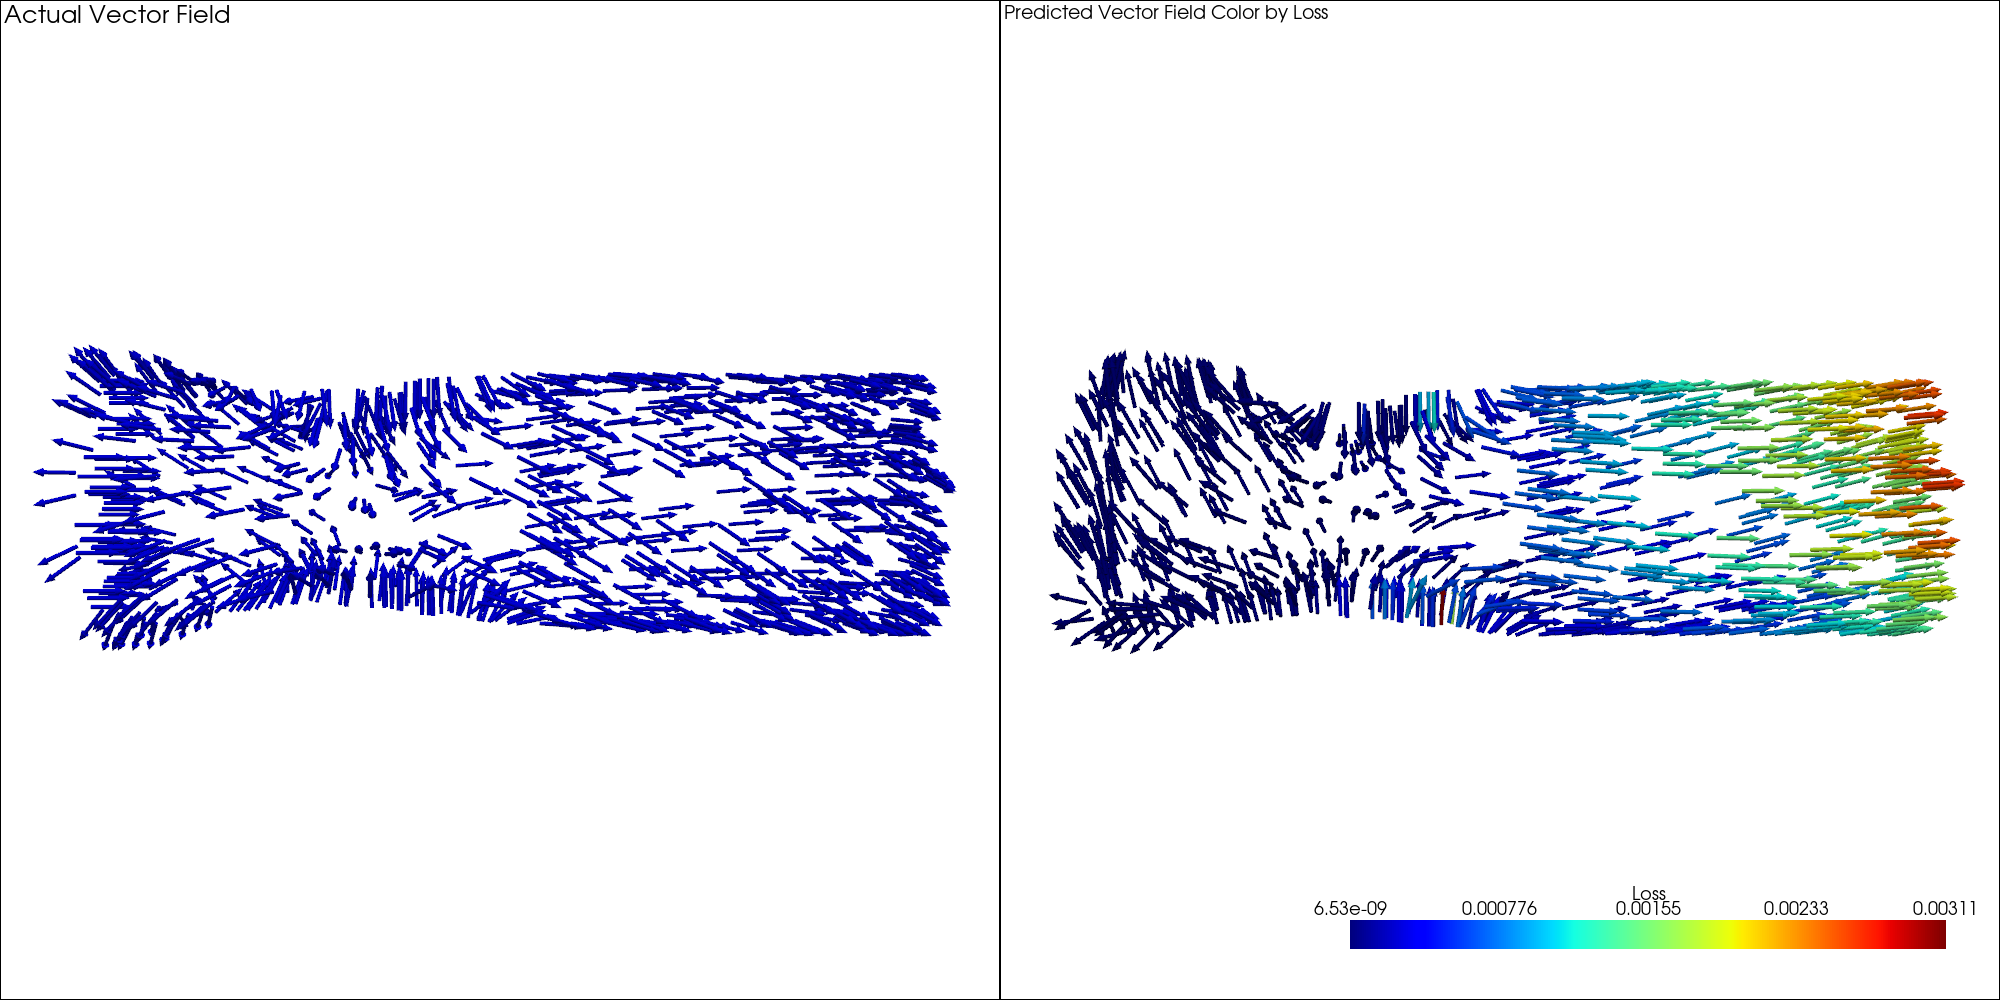

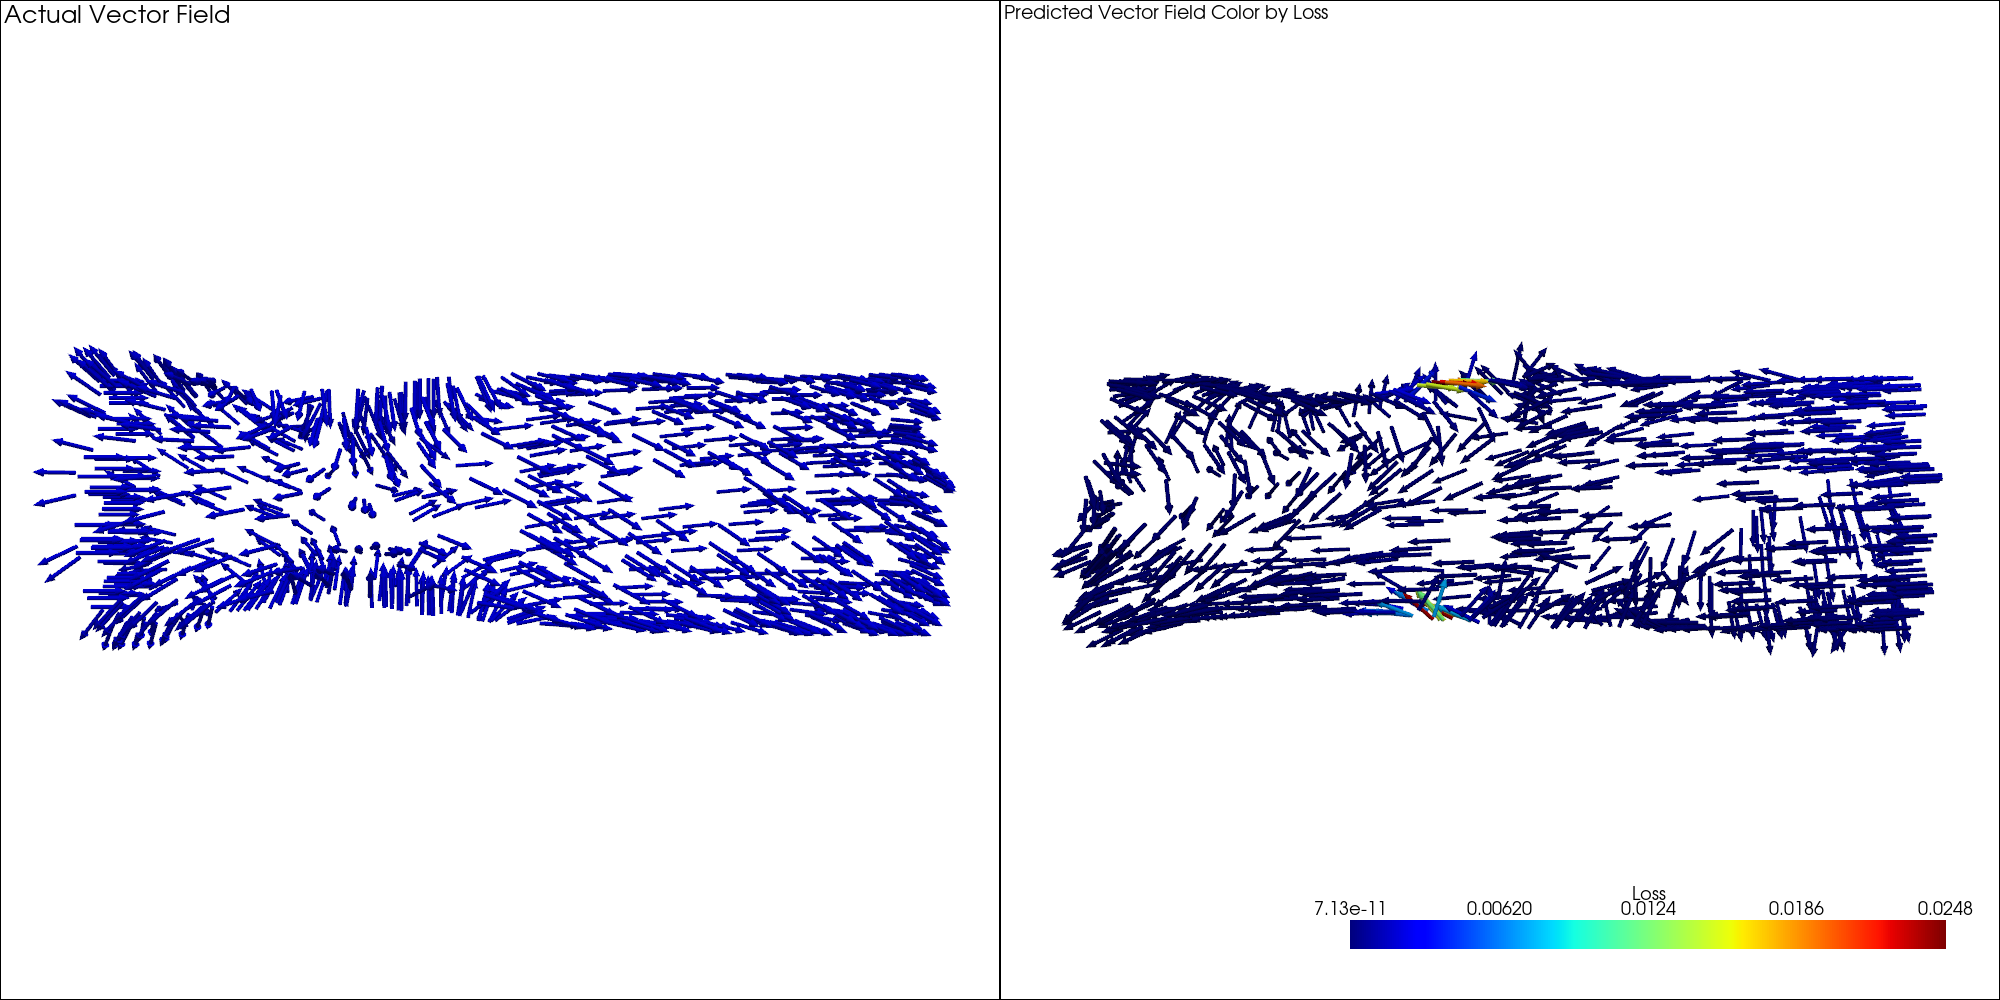

In [8]:
from IPython.display import Image, display

display(Image(filename=str(FORGE_NET_ROOT / "runs" / RUN_MSE / "eval" / "25" / "vector_fields_loss_25.png")))
display(Image(filename=str(FORGE_NET_ROOT / "runs" / RUN_CHAMFER / "eval" / "25" / "vector_fields_loss_25.png")))